In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("../images", exist_ok=True)

In [83]:
df = pd.read_csv('../data/raw/car_data.csv')

df.shape

(301, 9)

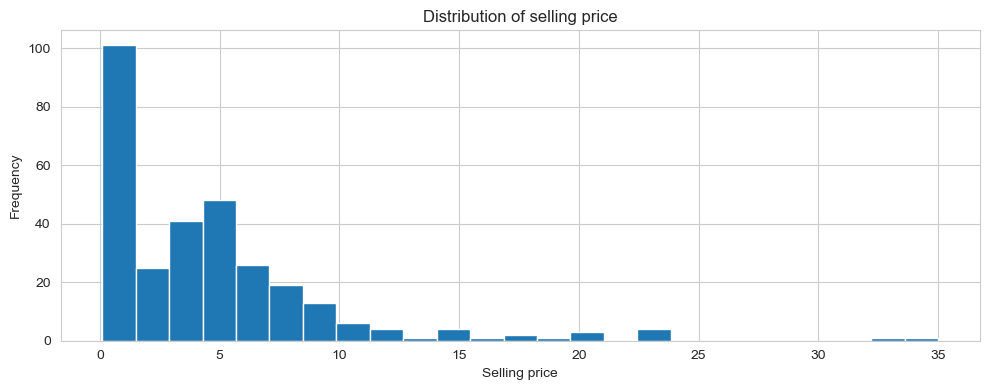

count    301.00
mean       4.66
std        5.08
min        0.10
25%        0.90
50%        3.60
75%        6.00
max       35.00
Name: Selling_Price, dtype: float64


In [84]:
# Plotting the distribution of selling price
df['Selling_Price'].hist(bins=25, figsize=(10, 4))

plt.title('Distribution of selling price')
plt.xlabel('Selling price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../images/02_selling_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['Selling_Price'].describe().round(2))

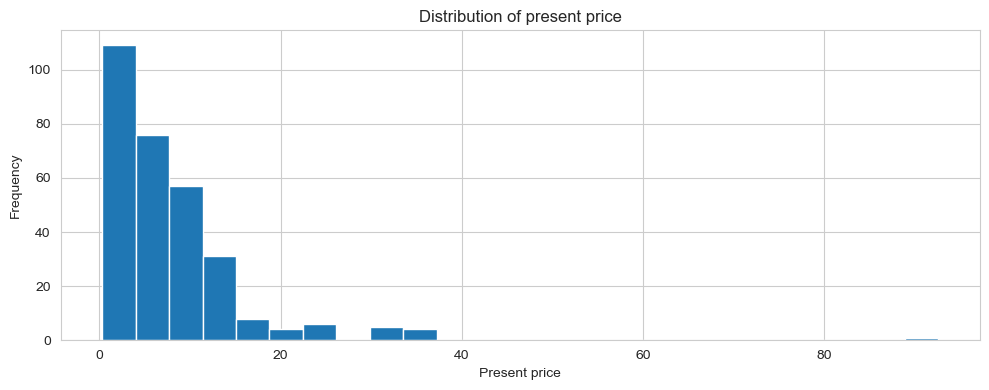

count    301.00
mean       7.63
std        8.64
min        0.32
25%        1.20
50%        6.40
75%        9.90
max       92.60
Name: Present_Price, dtype: float64


In [85]:
# Plotting the distribution of present price
df['Present_Price'].hist(bins=25, figsize=(10, 4))

plt.title('Distribution of present price')
plt.xlabel('Present price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../images/02_present_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['Present_Price'].describe().round(2))

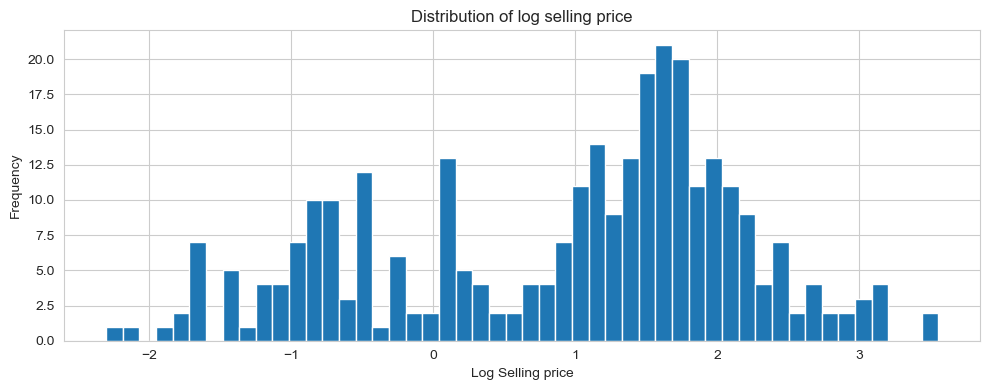

count    301.00
mean       0.91
std        1.27
min       -2.30
25%       -0.11
50%        1.28
75%        1.79
max        3.56
Name: Selling_Price, dtype: float64


In [86]:
# Plotting the distribution of selling price
np.log(df['Selling_Price']).hist(bins=50, figsize=(10, 4))

plt.title('Distribution of log selling price')
plt.xlabel('Log Selling price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../images/02_log_selling_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(np.log(df['Selling_Price']).describe().round(2))

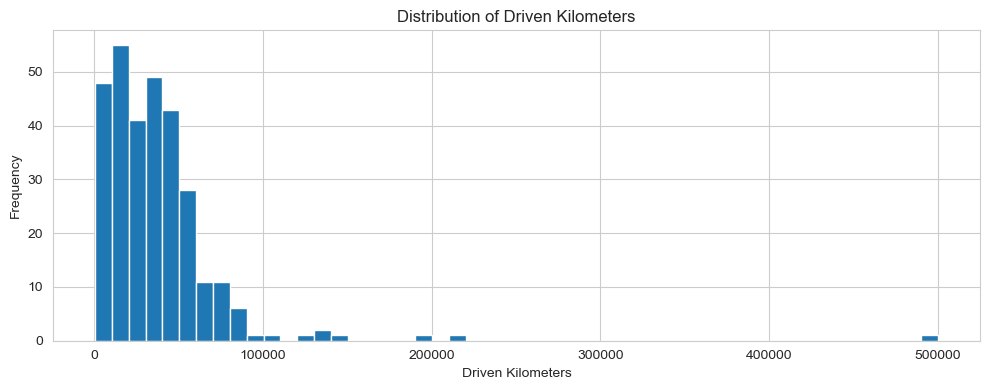

count       301.00
mean      36947.21
std       38886.88
min         500.00
25%       15000.00
50%       32000.00
75%       48767.00
max      500000.00
Name: Driven_kms, dtype: float64


In [87]:
# plotting the distribution of Driven Kilometers
df['Driven_kms'].hist(bins=50, figsize=(10, 4))

plt.title('Distribution of Driven Kilometers')
plt.xlabel('Driven Kilometers')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../images/02_driven_kms_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['Driven_kms'].describe().round(2))

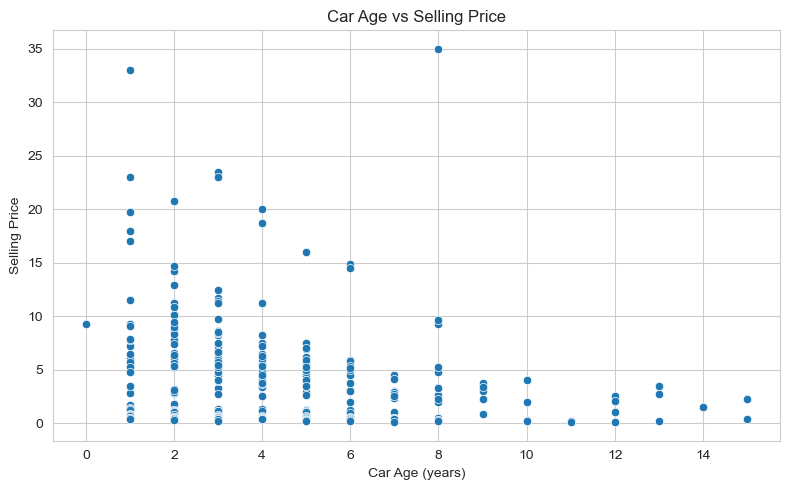

count    301.000000
mean       4.372093
std        2.891554
min        0.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       15.000000
Name: Car_Age, dtype: float64

In [88]:
# Plotting Car Age vs Selling Price
df['Car_Age'] = 2018 - df['Year']

sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))

sns.scatterplot(x='Car_Age', y='Selling_Price', data=df)

plt.xlabel("Car Age (years)")
plt.ylabel("Selling Price")
plt.title("Car Age vs Selling Price")
plt.tight_layout()
plt.savefig('../images/02_Car_Age_vs_Selling_Price.png', dpi=150, bbox_inches='tight')
plt.show()

df['Car_Age'].describe()

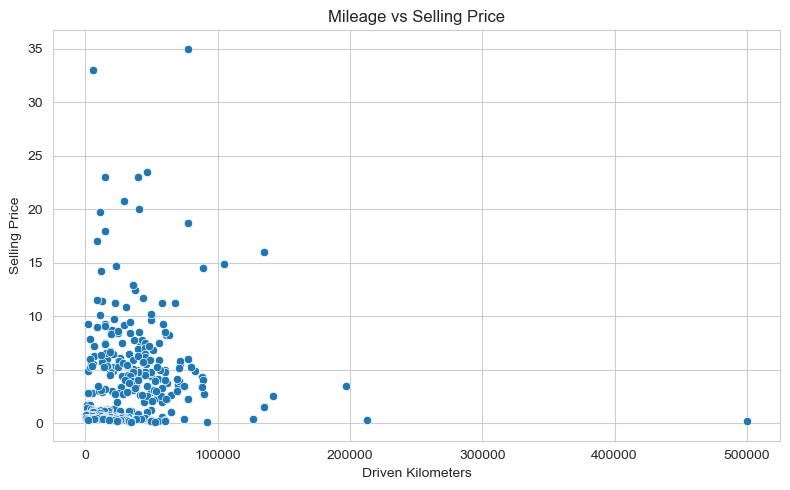

In [89]:
# Plotting Mileage vs Selling Price
plt.figure(figsize=(8, 5))

sns.scatterplot(x='Driven_kms', y='Selling_Price', data=df)

plt.title("Mileage vs Selling Price")
plt.xlabel("Driven Kilometers")
plt.ylabel("Selling Price")
plt.tight_layout()
plt.savefig("../images/02_mileage_vs_price.png", dpi=150, bbox_inches="tight")
plt.show()


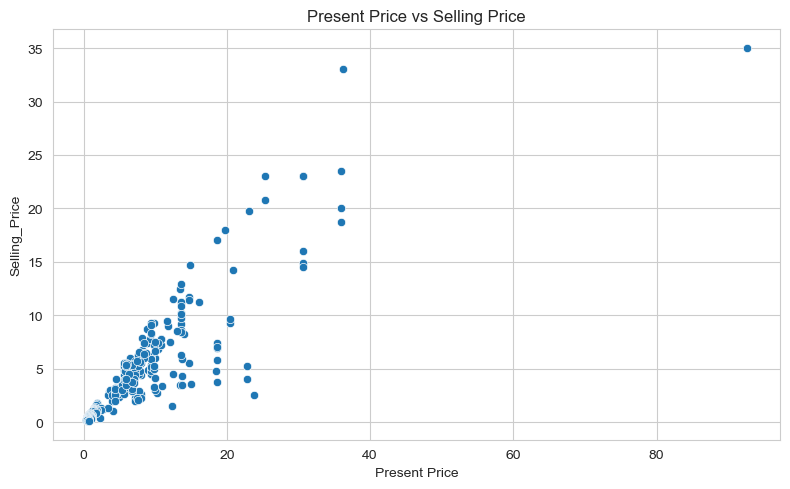

               Selling_Price  Present_Price
Selling_Price       1.000000       0.878914
Present_Price       0.878914       1.000000


In [90]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x='Present_Price', y='Selling_Price', data=df)

plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling_Price")
plt.tight_layout()
plt.savefig("../images/02_present_price_vs_selling_price.png", dpi=150, bbox_inches="tight")
plt.show()

# Both price correlation coefficient
corr = df[['Selling_Price', 'Present_Price']].corr()
print(corr)


Fuel_Type
CNG       3.10
Diesel    7.75
Petrol    2.65
Name: Selling_Price, dtype: float64
Transmission
Automatic    5.80
Manual       3.25
Name: Selling_Price, dtype: float64
Selling_type
Dealer        5.250
Individual    0.515
Name: Selling_Price, dtype: float64


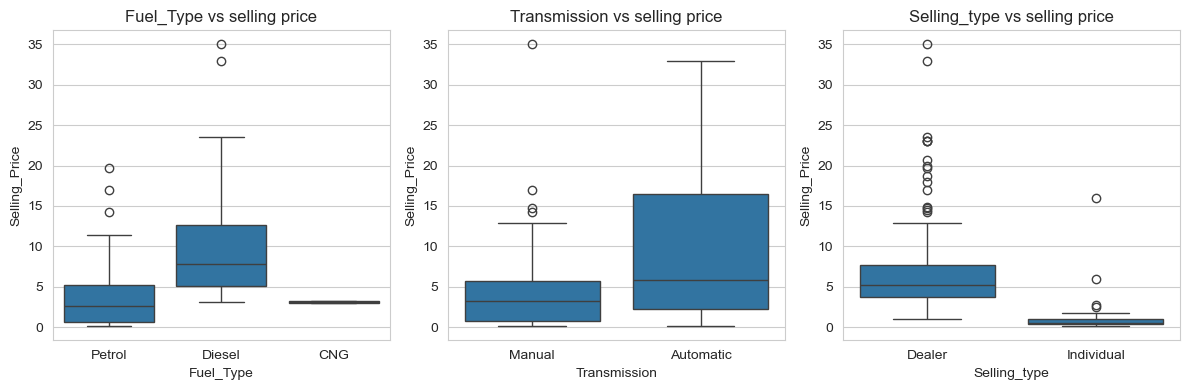

In [91]:
cols = ['Fuel_Type', 'Transmission', 'Selling_type']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, cols):
    sns.boxplot(
        data=df,
        x=col,
        y='Selling_Price',
        ax=ax
    )
    
    ax.set_title(f'{col} vs selling price')
    print(df.groupby(col)['Selling_Price'].median())

plt.tight_layout()
plt.savefig('../images/02_categorical_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


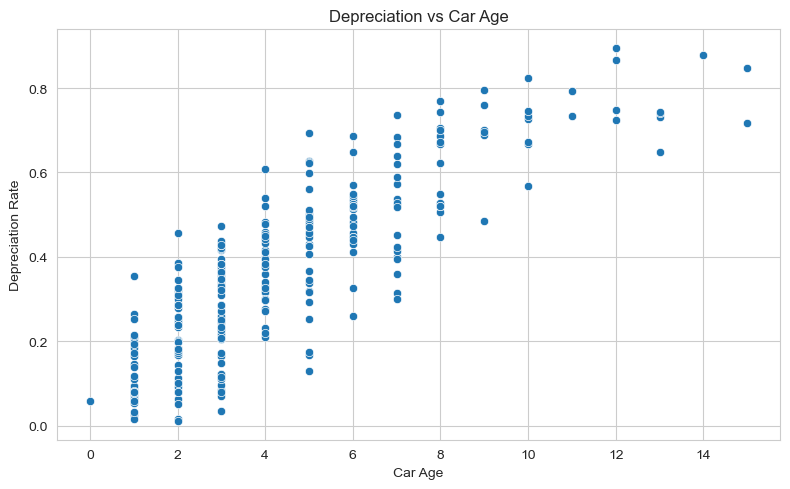

count    301.000000
mean       0.365760
std        0.202295
min        0.010745
25%        0.210526
50%        0.345745
75%        0.494949
max        0.894648
Name: Depreciation, dtype: float64


In [92]:
df['Depreciation'] = 1 - (df['Selling_Price'] / df['Present_Price'])

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Car_Age',
    y='Depreciation'
)

plt.title("Depreciation vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Depreciation Rate")
plt.tight_layout()
plt.savefig('../images/02_depreciation_vs_car_age.png', dpi=150, bbox_inches='tight')
plt.show()

print(df['Depreciation'].describe())

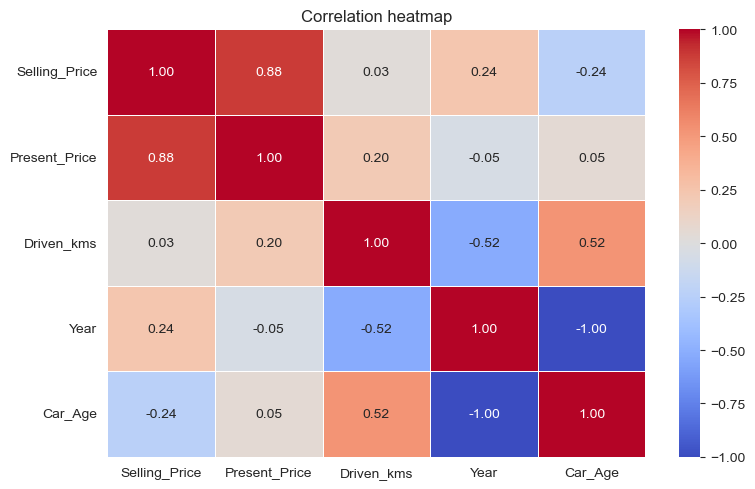

In [93]:
cols = ['Selling_Price', 'Present_Price', 'Driven_kms', 'Year', 'Car_Age']

corr = df[cols].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig("../images/02_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Findings from EDA

### Price distributions
- Selling_Price: mean 4.66 Lakhs, median 3.60, right-skewed (max 35.00 vs 75th percentile of 6.00)
- Present_Price: mean 7.63 Lakhs, median 6.40, also right-skewed (max 92.60)
- log(Selling_Price) distribution is far more symmetric — confirms log transform is the right call for modelling
- Driven_kms: median 32,000 km, but the 500,000km outlier is clearly visible and isolated from the rest of the distribution

### Price depreciation by age
- Car_Age ranges 0–15 years (mean 4.37) — clear negative relationship with Selling_Price, older cars sell for less
- Depreciation ranges from 1.07% to 89.46% — the lowest belongs to a near-new car, confirming Present_Price >= Selling_Price holds across the full dataset

### Present_Price is the strongest single predictor
- Correlation between Present_Price and Selling_Price: **0.879**
- This confirms what a car costs new is by far the strongest signal for what it sells for used

### Categorical impact on median selling price
| Feature | Group | Median Selling_Price |
|---|---|---|
| Fuel_Type | Diesel | 7.75 |
| Fuel_Type | CNG | 3.10 |
| Fuel_Type | Petrol | 2.65 |
| Transmission | Automatic | 5.80 |
| Transmission | Manual | 3.25 |
| Selling_type | Dealer | 5.25 |
| Selling_type | Individual | 0.515 |

Diesel and Automatic cars command a clear premium. The Dealer vs Individual gap (5.25 vs 0.515) is the largest single split in the dataset — worth exploring further in feature engineering.

### Multicollinearity note
- Year and Car_Age are perfectly inversely correlated (by construction) — only one should enter the model, not both

### Next step
Data cleaning — drop the 2 duplicate rows, investigate the 500,000km outlier, and decide on the CNG fuel type (2 entries).